# Cookie Monster — Explorer
Run cells top-to-bottom. The browser stays open between cells so you can inspect multiple stores without relaunching.

In [1]:
import sys, json, pprint
sys.path.insert(0, '.')   # make sure project root is on the path

from playwright.async_api import async_playwright
from scraper.browser import make_context, collect_json_responses
from scraper.locations import get_all_stores, LOCATIONS_URL
from scraper.menu import get_store_menu, BASE_URL, POS_GRAPHQL_HOST

print('imports ok')

imports ok


## 1 — Launch browser
Run once. Keep this cell's output — it shows the browser is alive.

In [2]:
pw  = await async_playwright().start()
browser = await pw.chromium.launch(headless=True)
ctx = await make_context(browser)
print('browser ready')

browser ready


## 2 — Fetch all store slugs

In [3]:
stores = await get_all_stores(ctx)
print(f'{len(stores)} stores found')
stores[:5]   # preview first 5

1108 stores found


[Store(slug='tx114th', name='114th', city='Lubbock', state='Texas'),
 Store(slug='41ststreet', name='41st Street', city='Sioux Falls', state='South Dakota'),
 Store(slug='ok71ststreet', name='71st Street', city='Tulsa', state='Oklahoma'),
 Store(slug='7thstreet', name='7th Street', city='Fort Worth', state='Texas'),
 Store(slug='txabilene', name='Abilene', city='Abilene', state='Texas')]

## 3 — Inspect the raw locations JSON
Shows every JSON response captured during the locations page load. Good for understanding the full payload structure.

In [4]:
page = await ctx.new_page()
raw_responses = await collect_json_responses(page, LOCATIONS_URL)
await page.close()

print(f'{len(raw_responses)} JSON responses captured')
for i, r in enumerate(raw_responses):
    print(f'  [{i}] {r["status"]}  {r["url"][:90]}')

15 JSON responses captured
  [0] 200  https://firebase.googleapis.com/v1alpha/projects/-/apps/1:272765177112:web:2843dce61aa68d6
  [1] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/termsandconditions.json
  [2] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/privacy.json
  [3] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/order.json
  [4] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/catering.json
  [5] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/giftcards.json
  [6] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/login.json?next=%2Forder%
  [7] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US.json
  [8] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/stores.json
  [9] 200  https://maps.googleapis.com/maps/api/mapsjs/gen_204?csp_test=true
  [10] 200  https://tiles.openfreemap.org/styles/liberty
  [11] 20

In [8]:
# Pick the index of the stores.json response from the list above and inspect it
IDX = 4   # <-- change this
r = raw_responses[IDX]
print(r['url'])
pprint.pprint(r['body'], depth=3)

https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/catering.json
{'__N_SSG': True,
 'pageProps': {'_nextI18Next': {'initialI18nStore': {...},
                                'initialLocale': 'en-US',
                                'ns': [...],
                                'userConfig': {...}},
               'structuredData': {'@context': 'https://schema.org',
                                  '@type': 'Service',
                                  'areaServed': {...},
                                  'audience': {...},
                                  'description': 'Make every occasion a sweet '
                                                 "celebration with Crumbl's "
                                                 'dessert catering service.',
                                  'name': 'Crumbl Catering',
                                  'provider': {...},
                                  'serviceType': 'Catering',
                                  'url': 'http

## 4 — Fetch menu for a single store (parsed)

In [37]:
SLUG = 'ncapex'   # <-- change to any store slug

cookies = await get_store_menu(ctx, SLUG)
print(f'{len(cookies)} cookies at {SLUG}')
for c in cookies:
    print(f'  [{c.flavor_type:7}]  {c.cookie_name}  ({c.cookie_id})')

10 cookies at ncapex
  [weekly ]  Dubai Chocolate Brownie  (80b1d970-0668-11f0-80a1-ada6ea9b511f:Cookies)
  [weekly ]  Brookies & Cream Cookie ft. OREO®  (aef35c90-9985-11f0-b9a9-3d7e8fe16579:Cookies)
  [weekly ]  Cake Batter Blondie Cookie  (84147630-f5d7-11ec-8b63-15aafd6cd11d:Cookies)
  [weekly ]  Carrot Cake Cookie  (b11812a0-c8ed-11e9-bb2f-7bfd075da76f:Cookie)
  [classic]  Milk Chocolate Chip Cookie  (ecf4e7d0-c05f-11e9-933a-07fdcf36242c:Cookie)
  [classic]  Pink Sugar Cookie  (3c66e610-3496-11ef-8bb9-0544be1ef467:Cookies)
  [classic]  Cookies & Cream Cookie  (8c0c55d0-d2ab-11e9-aad0-13aed36b9dff:Cookie)
  [classic]  Brownie Batter Cookie  (f8f07390-9a49-11eb-ac72-9190a69cef02:Cookie)
  [classic]  Snickerdoodle Cookie  (4288a660-da63-11e9-b257-d14e3ba804d5:Cookie)
  [classic]  Celebration Cake Cookie  (90d3b850-db03-11e9-ae7a-d967dc3d85da:Cookie)


## 5 — Inspect the raw menu GraphQL JSON
Shows the full POS GraphQL payload before any parsing — useful for finding new fields.

In [42]:
SLUG = 'tx114th'   # <-- change to any store slug

page = await ctx.new_page()
raw_menu_responses = await collect_json_responses(page, BASE_URL.format(slug=SLUG))
await page.close()

print(f'{len(raw_menu_responses)} JSON responses captured')
for i, r in enumerate(raw_menu_responses):
    print(f'  [{i}] {r["status"]}  {r["url"][:90]}')

14 JSON responses captured
  [0] 200  https://firebase.googleapis.com/v1alpha/projects/-/apps/1:272765177112:web:2843dce61aa68d6
  [1] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/termsandconditions.json
  [2] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/privacy.json
  [3] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/order.json
  [4] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/catering.json
  [5] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/giftcards.json
  [6] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/login.json?next=%2Forder%
  [7] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US.json
  [8] 200  https://crumblcookies.com/_next/data/hIV_s6qU17iR_tTFSnhgu/en-US/stores.json
  [9] 200  https://maps.googleapis.com/maps/api/mapsjs/gen_204?csp_test=true
  [10] 200  https://api.crumbl.com/graphql
  [11] 202  https://pro

In [43]:
# Find the GraphQL menu response and drill in
menu_r = next(r for r in raw_menu_responses if POS_GRAPHQL_HOST in r['url'])

# Top-level keys
print('top-level keys:', list(menu_r['body']['data']['public']['sourceForStore'].keys()))

top-level keys: ['maximumSingleOrderSize', 'sourceId', 'storeId', 'type', 'allowedDaysToOrder', 'fulfillmentTimeAdjustmentThreshold', 'productSummary', 'products', 'businessHours', '__typename']


In [44]:
# Look at a single option entry in full
options = menu_r['body']['data']['public']['sourceForStore']['productSummary']['options']
print(f'{len(options)} raw options')
pprint.pprint(options[1], depth=8)   # change index to inspect different cookies

28 raw options
{'__typename': 'ProductSummaryOption',
 'option': {'__typename': 'ProductModifierOption',
            'availability': [{'__typename': 'AvailabilityDateRange',
                              'end': '2026-03-29T23:59:59+00:00',
                              'start': '2026-03-23T00:00:00+00:00'}],
            'endDate': None,
            'image': 'https://crumbl.video/4d8f989a-f339-4812-a626-c3f58af19d7b_DubaiBrownie_FlyingAerial_TECH.png',
            'maxCountPerOrder': None,
            'maxCountPerProduct': None,
            'metadata': {'__typename': 'ProductModifierOptionMetadata',
                         'allergyInformation': {'__typename': 'AllergyInformation',
                                                'dairy': None,
                                                'description': 'Wheat, Egg, '
                                                               'Milk, Soy, '
                                                               'Tree Nuts',
                

In [48]:
options[0]['option']['metadata']['calorieInformation']['total']
options[0]['option']['tagName']#['calorieInformation']['total']

'Secret Menu'

In [49]:
# Dump full raw JSON to a file for offline inspection
out_path = f'data/discovery/{SLUG}_menu_raw.json'
with open(out_path, 'w') as f:
    json.dump(menu_r['body'], f, indent=2)
print(f'saved → {out_path}')

saved → data/discovery/tx114th_menu_raw.json


## 6 — Close browser
Run when you're done exploring.

In [ ]:
await browser.close()
await pw.stop()
print('browser closed')

## 7 — Example Report

saved cookie_snapshot.png


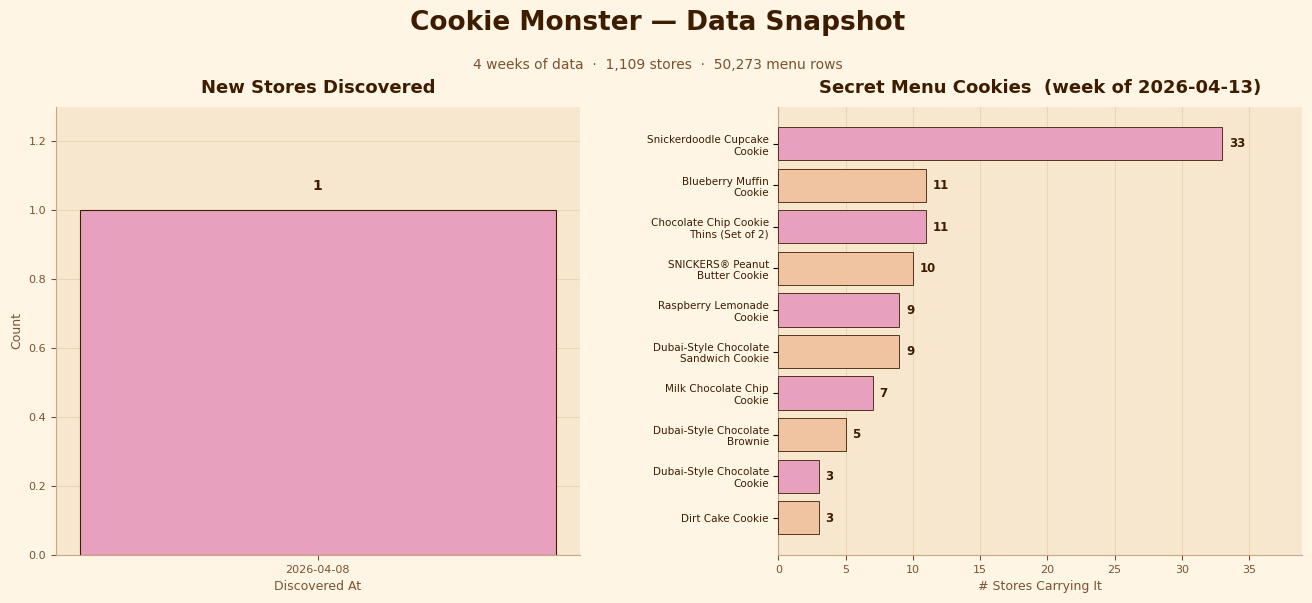

In [1]:
import sqlite3, pandas as pd, matplotlib, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

conn = sqlite3.connect('cookie_monster.db')
df_stores = pd.read_sql('SELECT * FROM stores', conn)
df_menus  = pd.read_sql('SELECT * FROM menu_items', conn)
conn.close()

# ── Query 1: new stores ──────────────────────────────────────────────────────
new_stores = df_stores[df_stores['discovered_at'] != df_stores['discovered_at'].min()]
q1 = new_stores['discovered_at'].value_counts().sort_index()

# ── Query 2: secret menu this week ──────────────────────────────────────────
latest_week = df_menus['week_of'].max()
q2 = (
    df_menus[(df_menus['week_of'] == latest_week) & (~df_menus['secret_menu'].isna())]
    ['cookie_name'].value_counts().head(10)
)

PINK   = '#E8A0BF'
CREAM  = '#FFF5E4'
BROWN  = '#3E1C00'
DARK   = '#1A0A00'
ACCENT = '#C1440E'
SOFT   = '#F7E7CE'

fig = plt.figure(figsize=(14, 7), facecolor=CREAM)
fig.patch.set_facecolor(CREAM)

gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38, left=0.07, right=0.96, top=0.82, bottom=0.18)

# ── TITLE BAR ───────────────────────────────────────────────────────────────
fig.text(0.5, 0.94, 'Cookie Monster — Data Snapshot', ha='center', va='center',
         fontsize=19, fontweight='bold', color=BROWN)
fig.text(0.5, 0.88, f'4 weeks of data  ·  {len(df_stores):,} stores  ·  {len(df_menus):,} menu rows',
         ha='center', va='center', fontsize=10, color='#7A5230')

# ── CHART 1: New Stores ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(SOFT)

if len(q1) == 0:
    ax1.text(0.5, 0.5, 'No new stores\nsince first scrape', ha='center', va='center',
             fontsize=13, color='#7A5230', transform=ax1.transAxes)
    ax1.set_xticks([]); ax1.set_yticks([])
else:
    labels = [str(d)[:10] for d in q1.index]
    bars = ax1.bar(labels, q1.values, color=PINK, edgecolor=BROWN, linewidth=0.8, zorder=3)
    for bar, val in zip(bars, q1.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold', color=BROWN)
    ax1.set_ylim(0, max(q1.values) * 1.3)

ax1.set_title('New Stores Discovered', fontsize=13, fontweight='bold', color=BROWN, pad=10)
ax1.set_xlabel('Discovered At', fontsize=9, color='#7A5230')
ax1.set_ylabel('Count', fontsize=9, color='#7A5230')
ax1.tick_params(colors='#7A5230', labelsize=8)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#C8A882')
ax1.yaxis.grid(True, color='#E8D5BA', zorder=0)
ax1.set_axisbelow(True)

# ── CHART 2: Secret Menu ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(SOFT)

colors = [PINK if i % 2 == 0 else '#F0C4A0' for i in range(len(q2))]
bars = ax2.barh(q2.index[::-1], q2.values[::-1], color=colors[::-1],
                edgecolor=BROWN, linewidth=0.6, zorder=3)
for bar, val in zip(bars, q2.values[::-1]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8.5, fontweight='bold', color=BROWN)

ax2.set_xlim(0, max(q2.values) * 1.18)
ax2.set_title(f'Secret Menu Cookies  (week of {latest_week})', fontsize=13, fontweight='bold', color=BROWN, pad=10)
ax2.set_xlabel('# Stores Carrying It', fontsize=9, color='#7A5230')

# Wrap long cookie names
import textwrap
wrapped = [textwrap.fill(name, 22) for name in q2.index[::-1]]
ax2.set_yticks(range(len(wrapped)))
ax2.set_yticklabels(wrapped, fontsize=7.5, color=BROWN)

ax2.tick_params(axis='x', colors='#7A5230', labelsize=8)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#C8A882')
ax2.xaxis.grid(True, color='#E8D5BA', zorder=0)
ax2.set_axisbelow(True)

plt.savefig('cookie_snapshot.png', dpi=160, bbox_inches='tight', facecolor=CREAM)
print('saved cookie_snapshot.png')